In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch.nn.init as init
import torch.nn as nn
import torch.optim as optim

from collections import Counter
import re
import torch

import random
import torch

In [2]:
# Load the SMS Spam Collection dataset
df = pd.read_csv(
    r"C:\Users\m.arasteh\data\ecommerceDataset.csv",
    sep=",",
    header=None,
    names=["label", "text"]
)
# Display the first five samples
df.head()

,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [3]:
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first five rows after shuffling
df.head()

,label,text
0,Clothing & Accessories,BREGEO Men's Cotton Casual Blazer This one but...
1,Household,HealthSense Chef-Mate KS 50 Digital Kitchen Sc...
2,Books,Think & Grow Rich About the Author NAPOLEON HI...
3,Clothing & Accessories,ayushicreationa Women's Cotton Sports Padded B...
4,Electronics,BlueRigger High Speed Micro HDMI to HDMI Cable...


In [4]:
# Count the number of messages in each class
class_counts = df["label"].value_counts()

# Or you can use:
class_counts = df.label.value_counts()

print(class_counts)

label
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8670
Name: count, dtype: int64


In [5]:
# Split the dataset into training and testing sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Reset row indices
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples : {len(test_df)}")

Training samples: 40339
Testing samples : 10085


In [6]:
# Our label column contains values: ham and spam instead of 0 and 1
# We convert the labels to 0 and 1.
train_df["label"] = train_df["label"].map({
    "Household": 0,
    "Books": 1,
    "Electronics": 2,
    "Clothing & Accessories": 3,
})

test_df["label"] = test_df["label"].map({
    "Household": 0,
    "Books": 1,
    "Electronics": 2,
    "Clothing & Accessories": 3,
})

In [7]:
test_df.head()

,label,text
0,1,"Administrative Officer [AO] (NIACL, OICL, NICL..."
1,0,Bembika Newborn Layering Basket Stuffer Bump B...
2,2,JBL Flip 4 Portable Wireless Speaker with Powe...
3,1,147 Snooker and Pool Table Gloves (1 Piece) CL...
4,1,Grit: The Power of Passion and Perseverance Re...


In [8]:
# Check the labels.
print(train_df["label"].unique())

[1 0 2 3]


In [9]:
# Parameters
max_tokens = 10000
sequence_length = 30

def tokenize(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

     # Split on whitespace
    return text.split()

In [10]:
counter = Counter()

for text in df["text"]:
    counter.update(tokenize(text))

# Reserve two special tokens
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in counter.most_common(max_tokens - 2):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 10000


In [11]:
def vectorize(text):
    tokens = tokenize(text)

    ids = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    # Truncate
    ids = ids[:sequence_length]

    # Pad
    ids += [vocab["<PAD>"]] * (sequence_length - len(ids))

    return torch.tensor(ids, dtype=torch.long)

In [12]:
sample = train_df["text"].iloc[20]

print("Original text:")
print(sample)

print("\nToken IDs:")
print(vectorize(sample))

print("\nShape:")
print(vectorize(sample).shape)

Original text:
Jaipurcrafts Wall Sconces 40 cm Long With 6 Glass Cup Candle Holders And Bonus Tealight Candles (Set Of 2) Size:Design 2   Add extraordinary designer detail to any room with this beautiful JaipurCrafts wall sconce.This classic design is perfect for decorating your wall or as a statement gifting piece.

Token IDs:
tensor([5952,  144,    1,  616,  148,   88,    9,  125,  194,  652, 1276, 2266,
           3, 6817, 3828, 1516,   33,    4,   55,    1,   55,  389, 1889,  994,
        1599,    5,   54,  133,    9,   14])

Shape:
torch.Size([30])


In [13]:
import torch.nn as nn

vocab_size = len(vocab)
embedding_dim = 128

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=embedding_dim,
    padding_idx=0
)

In [14]:
from torch.utils.data import Dataset

class SMSDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        x = vectorize(self.texts[idx])

        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long         # in multiclass and using CrossEntropyLoss, dtype should be long.
        )

        return x, y

In [15]:
train_dataset = SMSDataset(train_df)
test_dataset = SMSDataset(test_df)

In [16]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [17]:
init.xavier_uniform_(embedding.weight)

Parameter containing:
tensor([[-1.9829e-02, -9.3892e-05,  2.4146e-02,  ..., -4.3686e-03,
          9.1992e-03,  1.5987e-02],
        [-1.4058e-02, -1.3299e-04,  1.0853e-02,  ..., -5.2916e-03,
          7.9901e-03,  4.5090e-03],
        [ 1.9584e-02,  4.2961e-04, -5.1299e-03,  ..., -2.3135e-02,
         -1.8834e-02, -2.1924e-02],
        ...,
        [-4.1216e-03,  6.2089e-03, -2.0422e-03,  ...,  5.0619e-03,
         -1.9184e-02, -2.3505e-02],
        [ 1.9065e-02, -2.3156e-02,  8.9244e-04,  ...,  1.5579e-02,
         -1.9005e-02, -8.0072e-03],
        [-1.7207e-02,  3.0730e-03, -1.5178e-02,  ...,  3.2866e-03,
          4.3892e-03,  1.1268e-02]], requires_grad=True)

In [18]:
# Two tokenized SMS messages
input_ids = torch.tensor([
    [324, 12, 48, 97, 5, 221, 0, 0],
    [42, 91, 7, 18, 5, 0, 0, 0]
])

# Convert token IDs into word embeddings
embedded = embedding(input_ids)

print("Input shape :", input_ids.shape)
print("Output shape:", embedded.shape)

Input shape : torch.Size([2, 8])
Output shape: torch.Size([2, 8, 128])


In [19]:
# ---------------------------------------------------------
# Select a random SMS message from the training dataset
# ---------------------------------------------------------
random_sentence = random.choice(train_df["text"])

print("Original Text:")
print(random_sentence)

# ---------------------------------------------------------
# Convert the text into token IDs
# ---------------------------------------------------------
token_ids = vectorize(random_sentence)

print("\nToken IDs:")
print(token_ids)

print("\nToken IDs Shape:")
print(token_ids.shape)

# ---------------------------------------------------------
# Add a batch dimension
# Shape: (sequence_length,) -> (1, sequence_length)
# ---------------------------------------------------------
token_ids = token_ids.unsqueeze(0)

print("\nInput to Embedding Layer:")
print(token_ids.shape)

# ---------------------------------------------------------
# Convert token IDs into embedding vectors
# ---------------------------------------------------------
embedded = embedding(token_ids)

print("\nEmbedding Tensor Shape:")
print(embedded.shape)

print("\nFirst two Word Embeddings:")
print(embedded[0, :1])

Original Text:
Lenity Girls Printed Cotton Panties and Camisole Slips/Vests, (Pack of 6- 3 Panties and 3 Vests) Lovely white color bloomers with bright prints .These printed blommers look colourful and attractive. Made from cotton, these regular-fit blommers are light in weight and skin friendly.

Token IDs:
tensor([   1,  270,  517,   62, 3022,    3, 3945,    1,  154,    4,  125,   66,
        3022,    3,   66, 6453, 2303,   99,   65,    1,    9,  981, 1521,   63,
         517,    1,   87, 3561,    3,  475])

Token IDs Shape:
torch.Size([30])

Input to Embedding Layer:
torch.Size([1, 30])

Embedding Tensor Shape:
torch.Size([1, 30, 128])

First two Word Embeddings:
tensor([[-0.0141, -0.0001,  0.0109, -0.0062, -0.0027, -0.0113,  0.0130,  0.0046,
          0.0041, -0.0237, -0.0160, -0.0085,  0.0200, -0.0149, -0.0242,  0.0028,
          0.0181, -0.0056,  0.0171, -0.0194,  0.0227, -0.0006, -0.0026, -0.0171,
         -0.0121,  0.0040, -0.0118, -0.0141, -0.0221, -0.0136,  0.0131, -0.0098,
 

In [20]:
class FeedForwardClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Feed-forward classifier
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):

        # Convert token IDs to word embeddings
        x = self.embedding(x)

        # Average the embeddings across the sequence dimension
        x = x.mean(dim=1)

        # Classification
        x = self.classifier(x)

        return x

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64
num_classes = 4

model_FFNN = FeedForwardClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes = num_classes
).to(device)

print(model_FFNN)

cpu
FeedForwardClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_FFNN.parameters(),
    lr=0.0001
)

In [23]:
def accuracy_fn(labels, outputs):

    predictions = torch.argmax(outputs, dim=1)
    accuracy = (predictions == labels).float().mean()

    return accuracy.item()

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, test_loader, epochs=10):

    # Move model to device
    model = model.to(device)

    # Store the training history
    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    num_epochs = epochs

    for epoch in range(num_epochs):

        # -----------------------
        # Training phase
        # -----------------------
        model.train()

        running_loss = 0.0
        running_accuracy = 0.0

        for inputs, labels in train_loader:

            # Move data to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs).squeeze()
            
            # Compute loss
            loss = criterion(outputs, labels)

            # Compute accuracy
            accuracy = accuracy_fn(labels, outputs)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            running_loss += loss.item()
            running_accuracy += accuracy


        # Average training metrics
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_accuracy = running_accuracy / len(train_loader)


        # -----------------------
        # Evaluation phase
        # -----------------------
        model.eval()

        test_loss = 0.0
        test_accuracy = 0.0

        with torch.no_grad():

            for inputs, labels in test_loader:

                # Move data to device
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs).squeeze()

                loss = criterion(outputs, labels)

                accuracy = accuracy_fn(labels, outputs)

                test_loss += loss.item()
                test_accuracy += accuracy


        # Average test metrics
        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_accuracy = test_accuracy / len(test_loader)


        # Store metrics
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)

        train_accuracies.append(epoch_train_accuracy)
        test_accuracies.append(epoch_test_accuracy)


        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {epoch_train_loss:.4f} "
            f"Train Accuracy: {epoch_train_accuracy:.4f} "
            f"Test Loss: {epoch_test_loss:.4f} "
            f"Test Accuracy: {epoch_test_accuracy:.4f}"
        )


    return train_losses, test_losses, train_accuracies, test_accuracies

In [25]:
train_losses_FFNN, test_losses_FFNN, train_accuracies_FFNN, test_accuracies_FFNN = train_model(
    model = model_FFNN,
    train_loader = train_loader,
    test_loader = test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 1.1594 Train Accuracy: 0.5222 Test Loss: 0.8514 Test Accuracy: 0.7298
Epoch [2/10] Train Loss: 0.6344 Train Accuracy: 0.8059 Test Loss: 0.4847 Test Accuracy: 0.8571
Epoch [3/10] Train Loss: 0.4122 Train Accuracy: 0.8812 Test Loss: 0.3640 Test Accuracy: 0.8987
Epoch [4/10] Train Loss: 0.3249 Train Accuracy: 0.9089 Test Loss: 0.3081 Test Accuracy: 0.9153
Epoch [5/10] Train Loss: 0.2769 Train Accuracy: 0.9229 Test Loss: 0.2731 Test Accuracy: 0.9283
Epoch [6/10] Train Loss: 0.2445 Train Accuracy: 0.9322 Test Loss: 0.2495 Test Accuracy: 0.9351
Epoch [7/10] Train Loss: 0.2205 Train Accuracy: 0.9393 Test Loss: 0.2315 Test Accuracy: 0.9409
Epoch [8/10] Train Loss: 0.2011 Train Accuracy: 0.9441 Test Loss: 0.2172 Test Accuracy: 0.9433
Epoch [9/10] Train Loss: 0.1850 Train Accuracy: 0.9500 Test Loss: 0.2056 Test Accuracy: 0.9476
Epoch [10/10] Train Loss: 0.1712 Train Accuracy: 0.9538 Test Loss: 0.1951 Test Accuracy: 0.9507


In [26]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    
    # Number of epochs
    epochs = range(1, len(train_losses) + 1)
    
    
    # Create subplots
    plt.figure(figsize=(12, 5))
    
    
    # -----------------------------
    # Plot Training and Test Loss
    # -----------------------------
    plt.subplot(1, 2, 1)
    
    plt.plot(
        epochs,
        train_losses,
        marker='o',
        label="Training Loss"
    )
    
    plt.plot(
        epochs,
        test_losses,
        marker='s',
        label="Test Loss"
    )
    
    plt.title("Training and Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    
    
    
    # -----------------------------
    # Plot Training and Test Accuracy
    # -----------------------------
    plt.subplot(1, 2, 2)
    
    plt.plot(
        epochs,
        train_accuracies,
        marker='o',
        label="Training Accuracy"
    )
    
    plt.plot(
        epochs,
        test_accuracies,
        marker='s',
        label="Test Accuracy"
    )
    
    plt.title("Training and Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    
    
    # Adjust spacing between plots
    plt.tight_layout()
    
    plt.show()


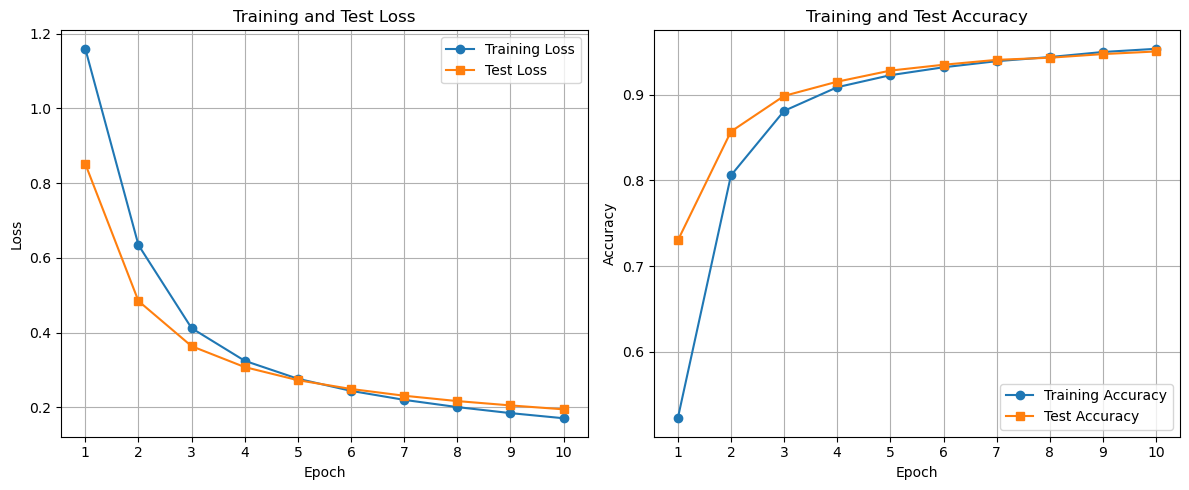

In [27]:
plot_loss_accuracy(epochs = 10, 
                   train_losses = train_losses_FFNN, 
                   test_losses = test_losses_FFNN, 
                   train_accuracies = train_accuracies_FFNN,
                  test_accuracies = test_accuracies_FFNN)

In [28]:

def evaluate(model):
    
    model.eval()
    
    total_accuracy = 0

    with torch.no_grad():

        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = model(inputs).squeeze()
            accuracy = accuracy_fn(labels, outputs)
            total_accuracy += accuracy
        
    test_accuracy = total_accuracy/len(test_loader)

    print(f"Test Accuracy: {test_accuracy:.4f}")

evaluate(model_FFNN)

Test Accuracy: 0.9507


In [29]:
def predict(text, model):
    
    class_names = [
        "Household",
        "Books",
        "Electronics",
        "Clothing & Accessories"
    ]
    
    model.eval()

    # Vetorize, change shape to (1, sequence_lenght) and move to the same device of model
    input_tensor = vectorize(text).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.sigmoid(outputs)
        prediction = torch.argmax(outputs, dim=1).item()

    return class_names[prediction]

In [30]:
text = "iPhone 17. Center Stage front camera. Latest-generation Ceramic Shield. 6.3-inch ProMotion display. A19 chip. Five gorgeous colors."
prediction = predict(text, model_FFNN)

print("Prediction:", prediction)

Prediction: Electronics


In [31]:
# Implement an RNN with one layer of RNN

class RNNClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )


        # Recurrent Neural Network layer
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,         # Number of RNN layer
            batch_first=True
        )


        # Fully connected classification layer
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=num_classes
        )


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)


        # Process the sequence using RNN
        output, hidden = self.rnn(x)


        # Remove the first dimension
        hidden = hidden[-1]


        # Convert hidden representation into prediction
        output = self.fc(hidden)

        return output

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64
num_classes = 4

model_RNN = RNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes = num_classes
).to(device)

print(model_RNN)

cpu
RNNClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (rnn): RNN(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_RNN.parameters(),
    lr=0.0001
)

In [34]:
train_losses_RNN, test_losses_RNN, train_accuracies_RNN, test_accuracies_RNN = train_model(
    model = model_RNN,
    train_loader = train_loader,
    test_loader = test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 1.3440 Train Accuracy: 0.3457 Test Loss: 1.2879 Test Accuracy: 0.4272
Epoch [2/10] Train Loss: 1.1940 Train Accuracy: 0.4906 Test Loss: 1.1042 Test Accuracy: 0.5460
Epoch [3/10] Train Loss: 1.0921 Train Accuracy: 0.5507 Test Loss: 1.0785 Test Accuracy: 0.5496
Epoch [4/10] Train Loss: 1.0518 Train Accuracy: 0.5656 Test Loss: 1.0308 Test Accuracy: 0.5762
Epoch [5/10] Train Loss: 1.0318 Train Accuracy: 0.5717 Test Loss: 1.0007 Test Accuracy: 0.5917
Epoch [6/10] Train Loss: 0.9628 Train Accuracy: 0.6044 Test Loss: 0.9544 Test Accuracy: 0.6086
Epoch [7/10] Train Loss: 0.9256 Train Accuracy: 0.6255 Test Loss: 0.8965 Test Accuracy: 0.6422
Epoch [8/10] Train Loss: 0.8179 Train Accuracy: 0.6779 Test Loss: 0.7812 Test Accuracy: 0.6923
Epoch [9/10] Train Loss: 0.7143 Train Accuracy: 0.7236 Test Loss: 0.6799 Test Accuracy: 0.7348
Epoch [10/10] Train Loss: 0.6281 Train Accuracy: 0.7641 Test Loss: 0.6089 Test Accuracy: 0.7760


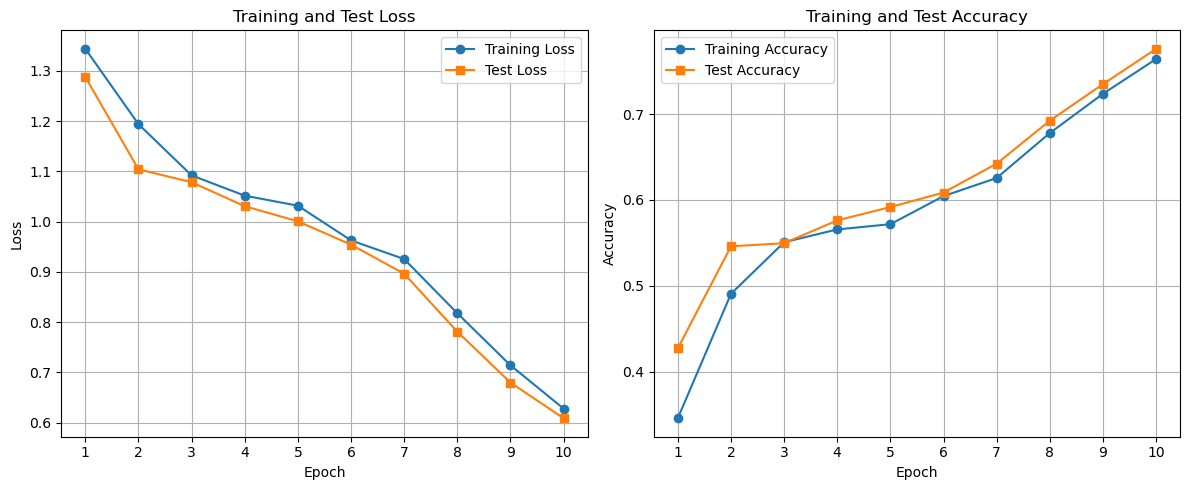

In [35]:
plot_loss_accuracy(epochs = 15, 
                   train_losses = train_losses_RNN, 
                   test_losses = test_losses_RNN, 
                   train_accuracies = train_accuracies_RNN,
                   test_accuracies = test_accuracies_RNN)

In [36]:
evaluate(model_RNN)

Test Accuracy: 0.7760


In [37]:
text = "iPhone 17. Center Stage front camera. Latest-generation Ceramic Shield. 6.3-inch ProMotion display. A19 chip. Five gorgeous colors."
prediction = predict(text, model_RNN)

print("Prediction:", prediction)

Prediction: Electronics


In [38]:
import torch
import torch.nn as nn


class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,           # Number io LSTM Layer
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features= num_classes
        )


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Process the sequence using LSTM
        output, (hidden, cell) = self.lstm(x)

        # Use the final hidden state
        hidden = hidden[-1]

        # Fully connected layer
        output = self.fc(hidden)

        return output

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64
num_classes = 4

model_LSTM = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes = num_classes
).to(device)

print(model_LSTM)

cpu
LSTMClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [40]:
import torch.optim as optim 

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_LSTM.parameters(), lr=0.0001)

In [41]:
train_losses_LSTM, test_losses_LSTM, train_accuracies_LSTM, test_accuracies_LSTM = train_model(
    model = model_LSTM,
    train_loader = train_loader,
    test_loader = test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 1.2534 Train Accuracy: 0.4290 Test Loss: 0.9833 Test Accuracy: 0.5709
Epoch [2/10] Train Loss: 0.7933 Train Accuracy: 0.6846 Test Loss: 0.6221 Test Accuracy: 0.7840
Epoch [3/10] Train Loss: 0.5054 Train Accuracy: 0.8442 Test Loss: 0.3911 Test Accuracy: 0.8869
Epoch [4/10] Train Loss: 0.3320 Train Accuracy: 0.9091 Test Loss: 0.3067 Test Accuracy: 0.9147
Epoch [5/10] Train Loss: 0.2585 Train Accuracy: 0.9335 Test Loss: 0.2534 Test Accuracy: 0.9327
Epoch [6/10] Train Loss: 0.2181 Train Accuracy: 0.9449 Test Loss: 0.2245 Test Accuracy: 0.9423
Epoch [7/10] Train Loss: 0.1878 Train Accuracy: 0.9536 Test Loss: 0.2134 Test Accuracy: 0.9444
Epoch [8/10] Train Loss: 0.1673 Train Accuracy: 0.9592 Test Loss: 0.1984 Test Accuracy: 0.9499
Epoch [9/10] Train Loss: 0.1500 Train Accuracy: 0.9643 Test Loss: 0.1964 Test Accuracy: 0.9511
Epoch [10/10] Train Loss: 0.1368 Train Accuracy: 0.9678 Test Loss: 0.1833 Test Accuracy: 0.9548


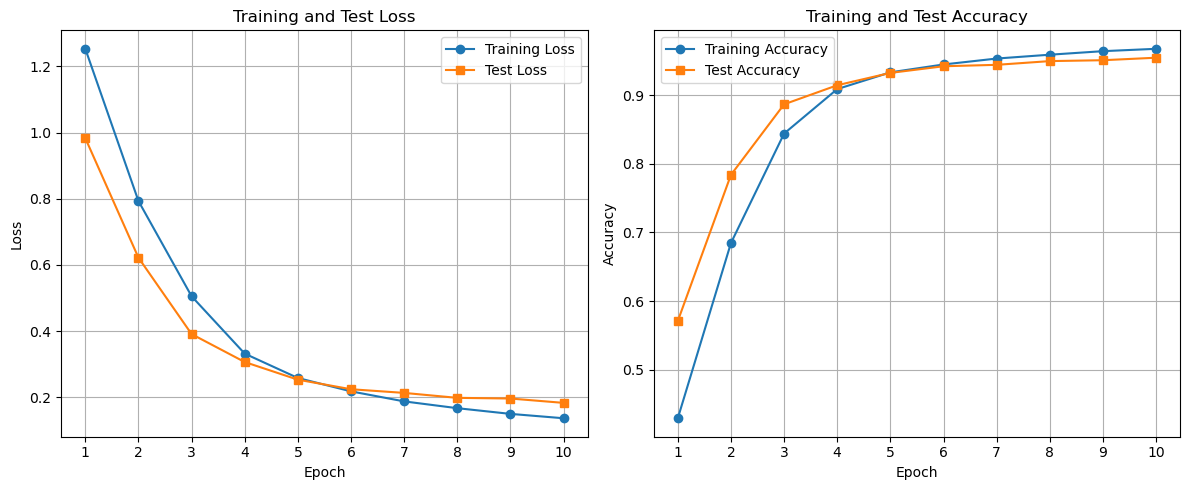

In [42]:
plot_loss_accuracy(epochs = 10, 
                   train_losses = train_losses_LSTM, 
                   test_losses = test_losses_LSTM, 
                   train_accuracies = train_accuracies_LSTM,
                   test_accuracies = test_accuracies_LSTM)

In [43]:
evaluate(model_LSTM)

Test Accuracy: 0.9548


In [44]:
text = "iPhone 17. Center Stage front camera. Latest-generation Ceramic Shield. 6.3-inch ProMotion display. A19 chip. Five gorgeous colors."
prediction = predict(text, model_LSTM)

print("Prediction:", prediction)

Prediction: Electronics


In [45]:
# Implement a GRU Model

import torch
import torch.nn as nn


class GRUClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # GRU layer
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,       # Number of GRU layers
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=num_classes
        )


    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Process the sequence using GRU
        output, hidden = self.gru(x)

        # Use the final hidden state
        hidden = hidden[-1]

        # Fully connected layer
        output = self.fc(hidden)

        return output

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 64
num_classes = 4

model_GRU = GRUClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes = num_classes
).to(device)

print(model_GRU)

cpu
GRUClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (gru): GRU(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_GRU.parameters(),
    lr=0.0001
)

In [48]:
train_losses_GRU, test_losses_GRU, \
train_accuracies_GRU, test_accuracies_GRU = train_model(
    model=model_GRU,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 1.2298 Train Accuracy: 0.4356 Test Loss: 0.9642 Test Accuracy: 0.5843
Epoch [2/10] Train Loss: 0.8622 Train Accuracy: 0.6372 Test Loss: 0.6726 Test Accuracy: 0.7525
Epoch [3/10] Train Loss: 0.5012 Train Accuracy: 0.8392 Test Loss: 0.3691 Test Accuracy: 0.8931
Epoch [4/10] Train Loss: 0.3019 Train Accuracy: 0.9174 Test Loss: 0.2734 Test Accuracy: 0.9233
Epoch [5/10] Train Loss: 0.2369 Train Accuracy: 0.9389 Test Loss: 0.2350 Test Accuracy: 0.9370
Epoch [6/10] Train Loss: 0.2003 Train Accuracy: 0.9506 Test Loss: 0.2085 Test Accuracy: 0.9473
Epoch [7/10] Train Loss: 0.1753 Train Accuracy: 0.9584 Test Loss: 0.1940 Test Accuracy: 0.9514
Epoch [8/10] Train Loss: 0.1555 Train Accuracy: 0.9646 Test Loss: 0.1828 Test Accuracy: 0.9551
Epoch [9/10] Train Loss: 0.1417 Train Accuracy: 0.9680 Test Loss: 0.1792 Test Accuracy: 0.9560
Epoch [10/10] Train Loss: 0.1289 Train Accuracy: 0.9714 Test Loss: 0.1720 Test Accuracy: 0.9583


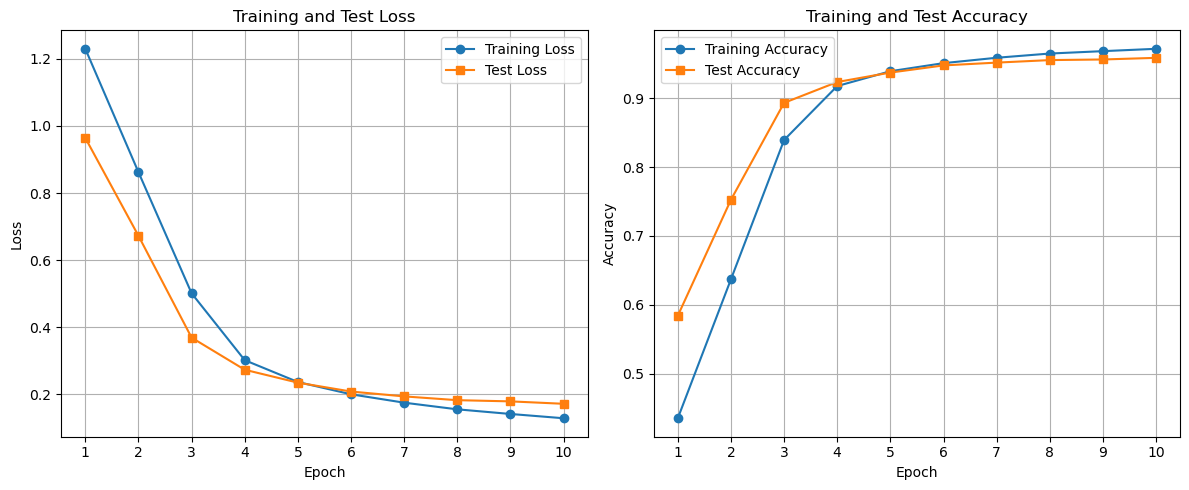

In [49]:
plot_loss_accuracy(
    epochs=10,
    train_losses=train_losses_GRU,
    test_losses=test_losses_GRU,
    train_accuracies=train_accuracies_GRU,
    test_accuracies=test_accuracies_GRU
)

In [50]:
evaluate(model_GRU)

Test Accuracy: 0.9583


In [51]:
text = "iPhone 17. Center Stage front camera. Latest-generation Ceramic Shield. 6.3-inch ProMotion display. A19 chip. Five gorgeous colors."
prediction = predict(text, model_GRU)

print("Prediction:", prediction)

Prediction: Electronics


In [52]:
class TextCNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_filters,
        filter_sizes,
        num_classes
    ):

        super().__init__()

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Convolutional layers
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=filter_size
            )
            for filter_size in filter_sizes
        ])

        # Fully connected classification layer
        self.fc = nn.Linear(
            in_features=num_filters * len(filter_sizes),
            out_features=num_classes
        )

    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Rearrange dimensions for Conv1d
        x = x.permute(0, 2, 1)

        # Apply convolution + ReLU + max pooling
        pooled_outputs = []

        for conv in self.convs:

            feature_map = torch.relu(conv(x))

            pooled = torch.max(
                feature_map,
                dim=2
            ).values

            pooled_outputs.append(pooled)

        # Concatenate pooled features
        x = torch.cat(
            pooled_outputs,
            dim=1
        )

        # Classification
        x = self.fc(x)

        return x

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size = len(vocab)
embedding_dim = 128
num_filters = 64
filter_sizes = [2, 3, 4]
num_classes = 4


model_CNN = TextCNNClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_filters=num_filters,
    filter_sizes=filter_sizes,
    num_classes = num_classes
).to(device)


print(model_CNN)

cpu
TextCNNClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 64, kernel_size=(2,), stride=(1,))
    (1): Conv1d(128, 64, kernel_size=(3,), stride=(1,))
    (2): Conv1d(128, 64, kernel_size=(4,), stride=(1,))
  )
  (fc): Linear(in_features=192, out_features=4, bias=True)
)


In [54]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_CNN.parameters(),
    lr=0.0001
)

In [55]:
train_losses_CNN, test_losses_CNN, \
train_accuracies_CNN, test_accuracies_CNN = train_model(
    model=model_CNN,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 0.8025 Train Accuracy: 0.7156 Test Loss: 0.4737 Test Accuracy: 0.8729
Epoch [2/10] Train Loss: 0.3644 Train Accuracy: 0.9021 Test Loss: 0.3006 Test Accuracy: 0.9202
Epoch [3/10] Train Loss: 0.2424 Train Accuracy: 0.9364 Test Loss: 0.2301 Test Accuracy: 0.9385
Epoch [4/10] Train Loss: 0.1775 Train Accuracy: 0.9546 Test Loss: 0.1869 Test Accuracy: 0.9537
Epoch [5/10] Train Loss: 0.1335 Train Accuracy: 0.9667 Test Loss: 0.1600 Test Accuracy: 0.9598
Epoch [6/10] Train Loss: 0.1011 Train Accuracy: 0.9754 Test Loss: 0.1408 Test Accuracy: 0.9666
Epoch [7/10] Train Loss: 0.0764 Train Accuracy: 0.9836 Test Loss: 0.1247 Test Accuracy: 0.9686
Epoch [8/10] Train Loss: 0.0577 Train Accuracy: 0.9889 Test Loss: 0.1132 Test Accuracy: 0.9713
Epoch [9/10] Train Loss: 0.0427 Train Accuracy: 0.9926 Test Loss: 0.1054 Test Accuracy: 0.9734
Epoch [10/10] Train Loss: 0.0315 Train Accuracy: 0.9954 Test Loss: 0.0974 Test Accuracy: 0.9754


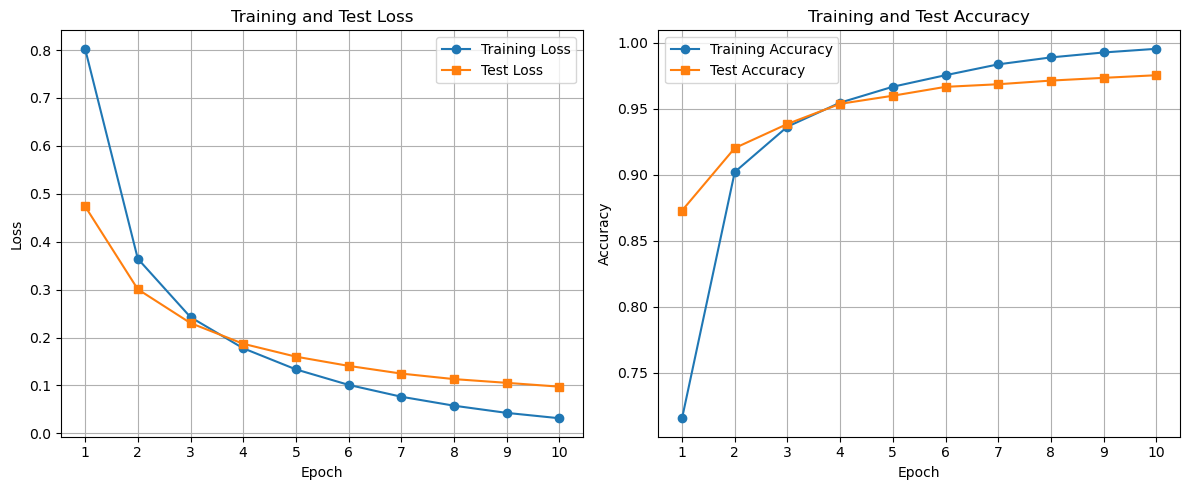

In [56]:
plot_loss_accuracy(
    epochs=10,
    train_losses=train_losses_CNN,
    test_losses=test_losses_CNN,
    train_accuracies=train_accuracies_CNN,
    test_accuracies=test_accuracies_CNN
)

In [57]:
evaluate(model_CNN)

Test Accuracy: 0.9754


In [58]:
text = "iPhone 17. Center Stage front camera. Latest-generation Ceramic Shield. 6.3-inch ProMotion display. A19 chip. Five gorgeous colors."
prediction = predict(text, model_CNN)

print("Prediction:", prediction)

Prediction: Electronics
